# I want to repurpose the existing code for visualizing our models' performances

In [4]:
# wait isn't this really hard to do?
# actually I could import the trainer class like in train_model.py, and see from there...
from omegaconf import OmegaConf
from rnn_trainer import BrainToTextDecoder_Trainer

args = OmegaConf.load('rnn_args.yaml')

In [5]:
"""
    We require in the YAML file that...
    - mode: x
    - save_best_checkpoint: False
    - init_from_checkpoint: True
"""
print(args['mode'])
print(args['save_best_checkpoint'])
print(args['init_from_checkpoint'])

print(args['output_dir']) # should be trained_models/<model>
print(args['checkpoint_dir']) # should be trained_models/<model>/checkpoint
print(args['init_checkpoint_path']) # should be trained_models/<model>/checkpoint/best_checkpoint
                                    # if the next cell doesn't work, it's because best_checkpoint is still best_checkpoint.zip
                                    # rename best_checkpoint.zip to best_checkpoint in that case.

x
False
True
trained_models/baseline_rnn_beta0.1
trained_models/baseline_rnn_beta0.1/checkpoint
trained_models/baseline_rnn_beta0.1/checkpoint/best_checkpoint


In [6]:
# Construct the full absolute path
import os
relative_path = args['init_checkpoint_path']
BASE_DIR = os.getcwd()
absolute_checkpoint_path = os.path.join(BASE_DIR, relative_path)
args['init_checkpoint_path'] = absolute_checkpoint_path

trainer = BrainToTextDecoder_Trainer(args)
model = trainer.model

2025-11-27 06:07:01,847: Using device: cuda:0
2025-11-27 06:07:02,302: Using torch.compile
2025-11-27 06:07:03,841: Initialized RNN decoding model
2025-11-27 06:07:03,841: OptimizedModule(
  (_orig_mod): GRUDecoder(
    (day_layer_activation): Softsign()
    (day_weights): ParameterList(
        (0): Parameter containing: [torch.float32 of size 512x512]
        (1): Parameter containing: [torch.float32 of size 512x512]
        (2): Parameter containing: [torch.float32 of size 512x512]
        (3): Parameter containing: [torch.float32 of size 512x512]
        (4): Parameter containing: [torch.float32 of size 512x512]
        (5): Parameter containing: [torch.float32 of size 512x512]
        (6): Parameter containing: [torch.float32 of size 512x512]
        (7): Parameter containing: [torch.float32 of size 512x512]
        (8): Parameter containing: [torch.float32 of size 512x512]
        (9): Parameter containing: [torch.float32 of size 512x512]
        (10): Parameter containing: [torc

In [7]:
import h5py
import torch
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# File paths
TRAIN_FILE = "../../data/hdf5_data_final/t15.2025.03.14/data_train.hdf5"
TEST_FILE = "../../data/hdf5_data_final/t15.2025.03.14/data_test.hdf5"

# --- Explore Data ---
def explore_data():
    print("Exploring training data...")
    with h5py.File(TRAIN_FILE, 'r') as f:
        trials = list(f.keys())
        print(f"Number of training trials: {len(trials)}")
        
        # Analyze sequence lengths and labels
        neural_lengths = []
        for trial_key in trials[:5]:
            trial = f[trial_key]
            neural_len = trial['input_features'].shape[0]
            label_len = trial['seq_class_ids'].shape[0]
            neural_lengths.append(neural_len)
            print(f"{trial_key}: neural={neural_len}, labels={label_len}")
            
        print(f"\nNeural length stats: min={min(neural_lengths)}, max={max(neural_lengths)}, avg={np.mean(neural_lengths):.1f}")

explore_data()

Using device: cuda
Exploring training data...
Number of training trials: 59
trial_0000: neural=950, labels=500
trial_0001: neural=932, labels=500
trial_0002: neural=939, labels=500
trial_0003: neural=701, labels=500
trial_0004: neural=513, labels=500

Neural length stats: min=513, max=950, avg=807.0


In [8]:
print(trainer.train_dataset)
print(trainer.train_loader)
print(trainer.val_dataset)
print(trainer.val_loader)

In [9]:
len(trainer.train_loader)

120000

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
def analyze_loader_batches(loader, name="Dataset", n_batches=3):
    """
    Analyze the first `n_batches` from a DataLoader.

    Note:
        - Each batch contains multiple trials.
        - This function only inspects the first `n_batches`.
        - It does NOT randomly sample trials across the whole dataset.
    """
    total_trials = 0
    total_time_steps = []
    total_seq_lens = []
    day_counts = {}

    print(f"\n{name}: analyzing first {n_batches} batches (sequential)")

    for batch_idx, batch in enumerate(loader):
        if batch_idx >= n_batches:
            break

        batch_size = batch['input_features'].shape[0]
        total_trials += batch_size

        total_time_steps.extend(batch['n_time_steps'].tolist())
        total_seq_lens.extend(batch['phone_seq_lens'].tolist())

        for d in batch['day_indicies'].tolist():
            day_counts[d] = day_counts.get(d, 0) + 1

    if total_trials == 0:
        print("No trials found in sampled batches!")
        return

    print(f"Total trials in sampled batches: {total_trials}")
    print(f"Input sequence lengths (time steps): min={min(total_time_steps)}, max={max(total_time_steps)}, mean={np.mean(total_time_steps):.2f}")
    print(f"Target sequence lengths (phonemes): min={min(total_seq_lens)}, max={max(total_seq_lens)}, mean={np.mean(total_seq_lens):.2f}")
    print(f"Days covered in sampled batches: {day_counts}")

# Analyze a few batches
analyze_loader_batches(trainer.train_loader, name="Training Dataset", n_batches=3)
analyze_loader_batches(trainer.val_loader, name="Validation Dataset", n_batches=3)


Training Dataset: analyzing first 3 batches (sequential)
Total trials in sampled batches: 192
Input sequence lengths (time steps): min=383, max=1931, mean=922.69
Target sequence lengths (phonemes): min=10, max=52, mean=27.05
Days covered in sampled batches: {3: 32, 2: 16, 30: 16, 21: 16, 8: 16, 43: 16, 16: 16, 17: 16, 13: 16, 38: 16, 12: 16}

Validation Dataset: analyzing first 3 batches (sequential)
Total trials in sampled batches: 132
Input sequence lengths (time steps): min=365, max=1203, mean=722.64
Target sequence lengths (phonemes): min=11, max=45, mean=25.86
Days covered in sampled batches: {1: 35, 2: 49, 3: 48}


In [12]:
from tqdm.notebook import tqdm

# OPTION = 1: quick validation
# ELSE: full validation
OPTION = 1

if OPTION == 1:
    n_trials_sample = 3
    val_trials = list(trainer.val_loader)[:n_trials_sample]
else:
    n_trials_sample = 41 # which matches with the YAML args, since 4 days have nothing in validation
    val_trials = list(trainer.val_loader)[:n_trials_sample]

# Run validation
metrics = trainer.validation(tqdm(val_trials), return_logits=True)

print("\n=== VALIDATION METRICS ===")
print(f"Average PER over sampled trials: {metrics['avg_PER']*100:.2f}%")
print(f"Average Loss over sampled trials: {metrics['avg_loss']:.4f}")

print("\nPER per day:")
for day, day_stats in metrics['day_PERs'].items():
    if day_stats['total_seq_length'] > 0:
        per = day_stats['total_edit_distance'] / day_stats['total_seq_length']
        print(f"  Day {day}: {per*100:.2f}%")

  0%|          | 0/3 [00:00<?, ?it/s]

W1127 06:07:47.659000 388265 site-packages/torch/_inductor/utils.py:1613] [4/0_1] Not enough SMs to use max_autotune_gemm mode
W1127 06:07:54.465000 388265 site-packages/torch/fx/experimental/symbolic_shapes.py:6833] [4/1] _maybe_guard_rel() was called on non-relation expression Eq(s77, 1) | Eq(s77, s59)
W1127 06:07:54.871000 388265 site-packages/torch/fx/experimental/symbolic_shapes.py:6833] [4/1_1] _maybe_guard_rel() was called on non-relation expression Eq(s77, 1) | Eq(s77, s59)
W1127 06:07:58.848000 388265 site-packages/torch/fx/experimental/symbolic_shapes.py:6833] [4/2] _maybe_guard_rel() was called on non-relation expression Eq(s77, 1) | Eq(s77, s59)
W1127 06:07:59.096000 388265 site-packages/torch/fx/experimental/symbolic_shapes.py:6833] [4/2_1] _maybe_guard_rel() was called on non-relation expression Eq(s77, 1) | Eq(s77, s59)



=== VALIDATION METRICS ===
Average PER over sampled trials: 6.00%
Average Loss over sampled trials: 10.7575

PER per day:
  Day 1: 7.28%
  Day 2: 5.45%
  Day 3: 5.56%


In [13]:
# there's a lot that could be done with these keys...
print(metrics.keys())

dict_keys(['logits', 'n_time_steps', 'decoded_seqs', 'true_seq', 'phone_seq_lens', 'transcription', 'losses', 'block_nums', 'trial_nums', 'day_indicies', 'day_PERs', 'avg_PER', 'avg_loss'])


# Creating Confusion Matrix from sampled validation batches

In [14]:
import numpy as np
import matplotlib.pyplot as plt

LOGIT_TO_PHONEME = [
    'BLANK', 'AA', 'AE', 'AH', 'AO', 'AW',
    'AY', 'B', 'CH', 'D', 'DH', 'EH', 'ER', 'EY', 'F', 'G',
    'HH', 'IH', 'IY', 'JH', 'K', 'L', 'M', 'N', 'NG', 'OW',
    'OY', 'P', 'R', 'S', 'SH', 'T', 'TH', 'UH', 'UW', 'V',
    'W', 'Y', 'Z', 'ZH', ' | ',
]

# create map excluding BLANK
phoneme_map = {i: ph for i, ph in enumerate(LOGIT_TO_PHONEME) if ph != 'BLANK'}
idx_map = {i: new_i for new_i, i in enumerate(phoneme_map.keys())}  # map old idx -> new idx
n_classes = len(phoneme_map)

conf_matrix = np.zeros((n_classes, n_classes), dtype=int)

for batch_idx in range(len(metrics['decoded_seqs'])):
    decoded_batch = metrics['decoded_seqs'][batch_idx]
    true_batch = metrics['true_seq'][batch_idx]
    phone_lens = metrics['phone_seq_lens'][batch_idx]

    for pred_seq, true_seq, seq_len in zip(decoded_batch, true_batch, phone_lens):
        true_seq_trim = true_seq[:seq_len]  # remove padding
        pred_seq_trim = [p for p in pred_seq if p != 0]  # remove blanks

        min_len = min(len(true_seq_trim), len(pred_seq_trim))
        for t, p in zip(true_seq_trim[:min_len], pred_seq_trim[:min_len]):
            if t in idx_map and p in idx_map:  # skip BLANKs
                conf_matrix[idx_map[t], idx_map[p]] += 1

# compute percent accuracy per class
true_counts = conf_matrix.sum(axis=1, keepdims=True)
conf_matrix_perc = conf_matrix / np.maximum(true_counts, 1) * 100

# Plotting Confusion Matrix

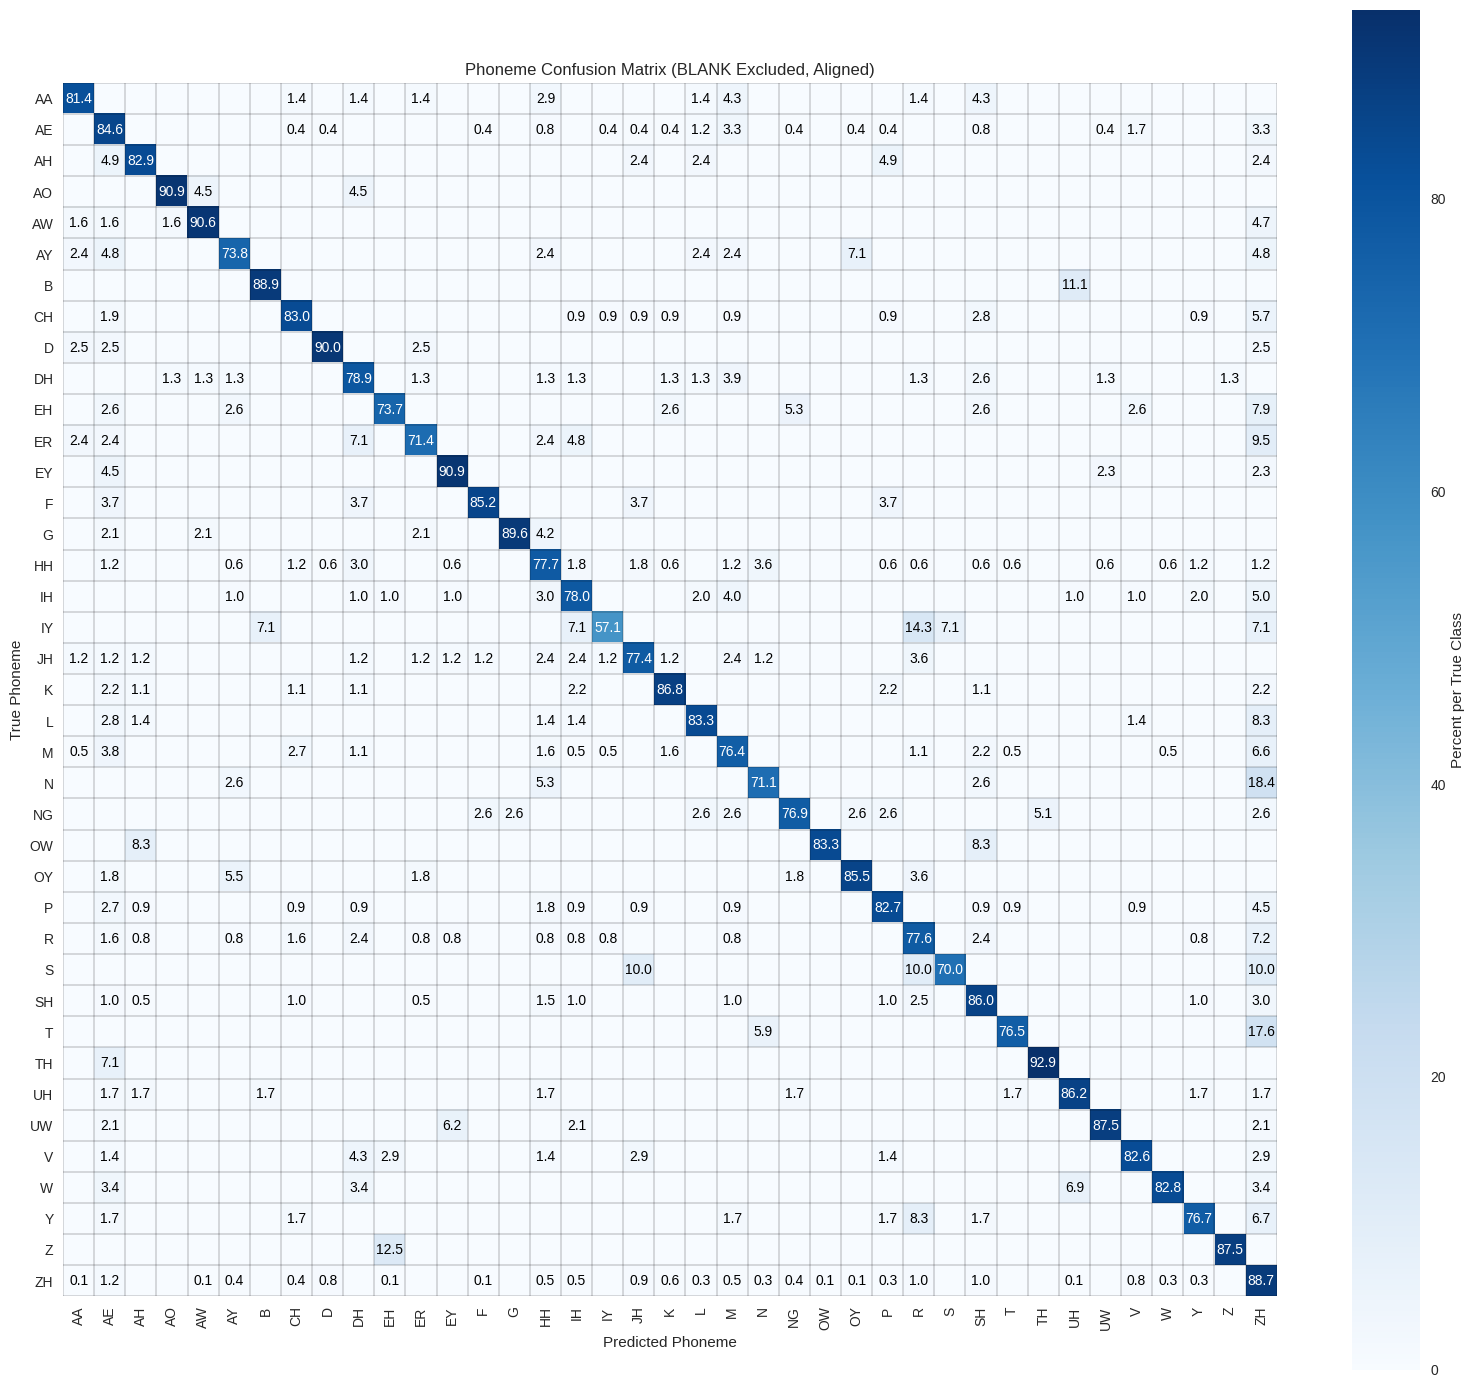

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Slice confusion matrix
conf_matrix_no_blank = conf_matrix[1:, 1:]
n_classes_no_blank = conf_matrix_no_blank.shape[0]

# Labels must match n_classes_no_blank exactly
phoneme_labels = LOGIT_TO_PHONEME[1:1+n_classes_no_blank]  # slice to length 39

# Normalize per true class
true_counts_no_blank = conf_matrix_no_blank.sum(axis=1, keepdims=True)
conf_matrix_perc_no_blank = conf_matrix_no_blank / np.maximum(true_counts_no_blank, 1) * 100

# Plot
fig, ax = plt.subplots(figsize=(16,14))
im = plt.imshow(conf_matrix_perc_no_blank, cmap=plt.cm.Blues, vmin=0, vmax=conf_matrix_perc_no_blank.max())

# Add annotations
for i in range(n_classes_no_blank):
    for j in range(n_classes_no_blank):
        if conf_matrix_perc_no_blank[i,j] > 0:
            plt.text(j, i, f"{conf_matrix_perc_no_blank[i,j]:.1f}",
                     ha="center", va="center",
                     color="white" if conf_matrix_perc_no_blank[i,j]>50 else "black")

# Tick labels
ax.set_xticks(np.arange(n_classes_no_blank))
ax.set_xticklabels(phoneme_labels, rotation=90)
ax.set_yticks(np.arange(n_classes_no_blank))
ax.set_yticklabels(phoneme_labels)

# Turn off gridlines / spines to remove “cross”
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

# Add thin black borders between cells
ax.set_xticks(np.arange(-0.5, n_classes_no_blank, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_classes_no_blank, 1), minor=True)
ax.grid(which='minor', color='black', linestyle='-', linewidth=0.2)

plt.colorbar(im, label='Percent per True Class')
plt.xlabel("Predicted Phoneme")
plt.ylabel("True Phoneme")
plt.title("Phoneme Confusion Matrix (BLANK Excluded, Aligned)")
plt.tight_layout()
plt.show()

# Decoding Phonemes

In [16]:
def decode_phonemes(decoded_seqs, mapping=LOGIT_TO_PHONEME):
    all_sequences = []
    for batch in decoded_seqs:
        batch_seqs = []
        for seq in batch:
            # Map indices to phonemes
            phonemes = [mapping[i] for i in seq]

            # Remove 'BLANK's
            phonemes = [p for p in phonemes if p != 'BLANK']

            # Collapse consecutive ' | '
            collapsed = []
            for p in phonemes:
                if p != ' | ':
                    collapsed.append(p)
                else:
                    if len(collapsed) == 0 or collapsed[-1] != '|':
                        collapsed.append('|')

            # Join as string and strip leading/trailing '|'
            s = ' '.join(collapsed).strip()
            if s.startswith('|'):
                s = s[1:].strip()
            if s.endswith('|'):
                s = s[:-1].strip()

            batch_seqs.append(s)
        all_sequences.append(batch_seqs)
    return all_sequences

# Example usage
readable_seqs = decode_phonemes(metrics['decoded_seqs'])
print(readable_seqs[0][:1])

['Y UW | K AE N | S IY | DH AH | K OW D | AE T | DH IH S | P OY N T | AE Z | W IH L']
